(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

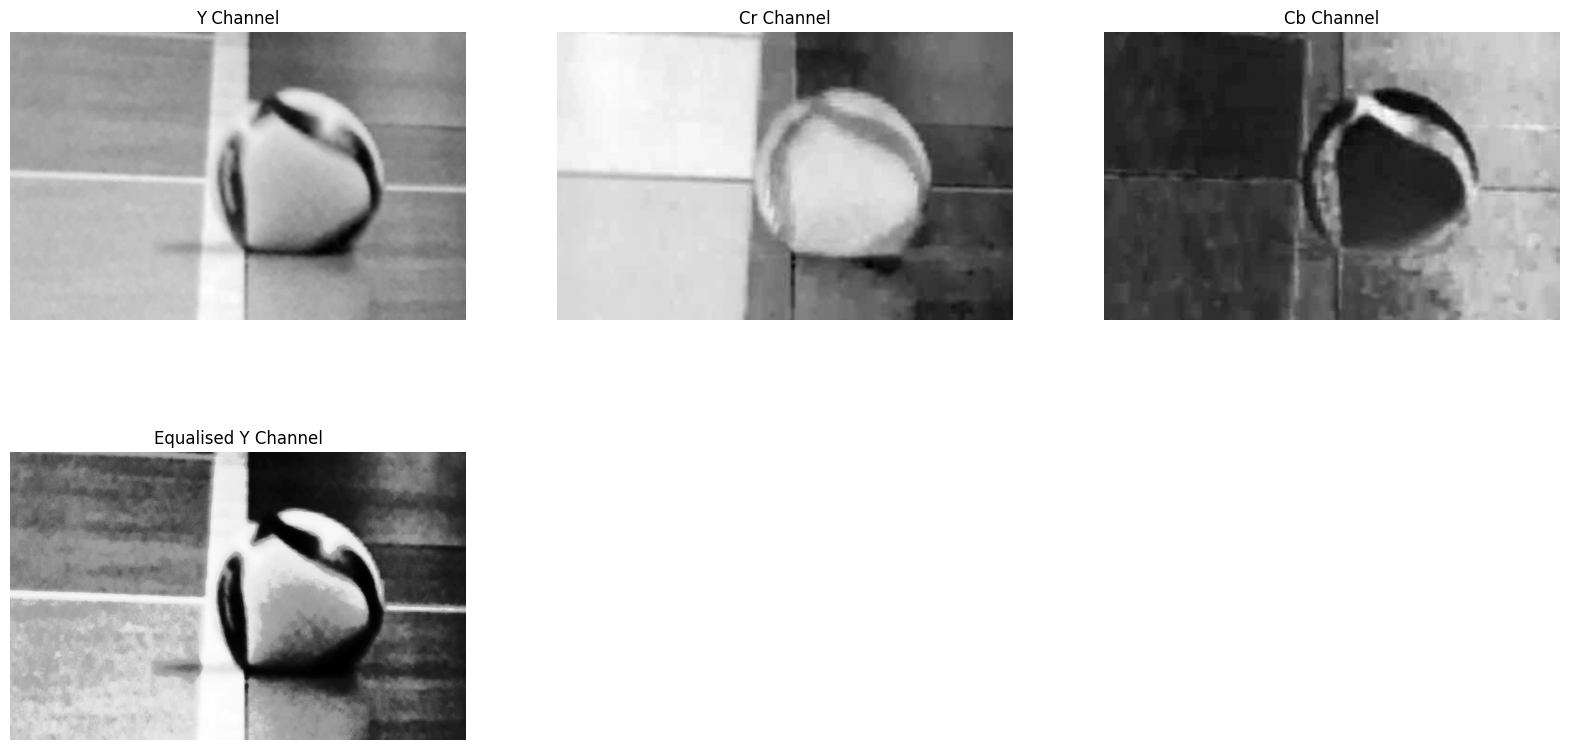

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread('images/Sample_Input.jpg')

YCrCb = cv.cvtColor(image, cv.COLOR_BGR2YCrCb)

Y, Cr, Cb = cv.split(YCrCb)
equalised_y = cv.equalizeHist(Y)
YCrCb_eq = cv.merge((equalised_y, Cr, Cb))

plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
plt.title('Y Channel')
plt.imshow(Y, cmap='gray')
plt.axis('off')
plt.subplot(2,3,2)
plt.title('Cr Channel')
plt.imshow(Cr, cmap='gray')
plt.axis('off')
plt.subplot(2,3,3)
plt.title('Cb Channel')
plt.imshow(Cb, cmap='gray')
plt.axis('off')
plt.subplot(2,3,4)
plt.title('Equalised Y Channel')
plt.imshow(equalised_y, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

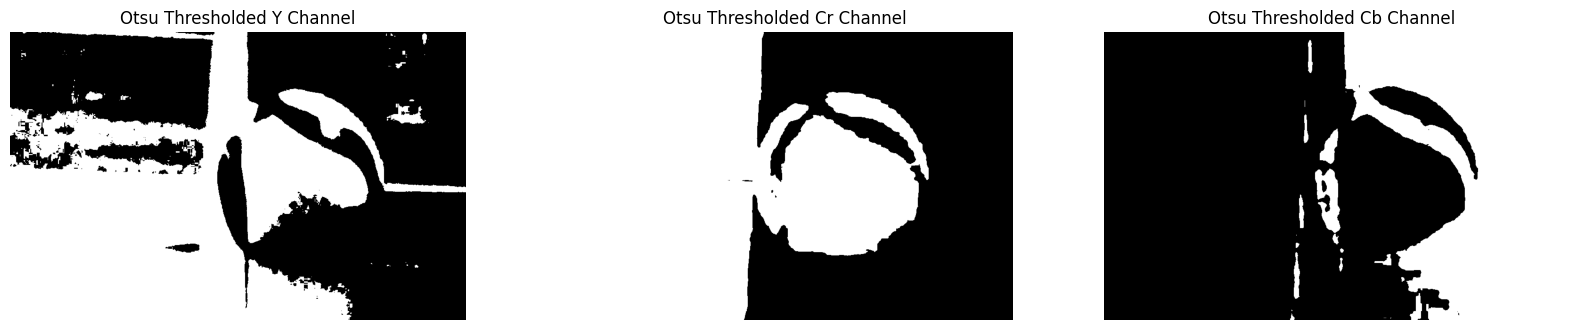

In [3]:
# Otsu threshold on Y, Cr, Cb channels
_, y_thresh = cv.threshold(Y, thresh=0, maxval=255, type=cv.THRESH_BINARY + cv.THRESH_OTSU)
_, thresh_cr = cv.threshold(Cr, thresh=120, maxval=255, type=cv.THRESH_BINARY + cv.THRESH_OTSU)
_, thresh_cb = cv.threshold(Cb, thresh=130, maxval=255, type=cv.THRESH_BINARY + cv.THRESH_OTSU)

plt.figure(figsize=(20,10))
plt.subplot(1,3,1)
plt.title('Otsu Thresholded Y Channel')
plt.imshow(y_thresh, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title('Otsu Thresholded Cr Channel')
plt.imshow(thresh_cr, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title('Otsu Thresholded Cb Channel')
plt.imshow(thresh_cb, cmap='gray')
plt.axis('off')


(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

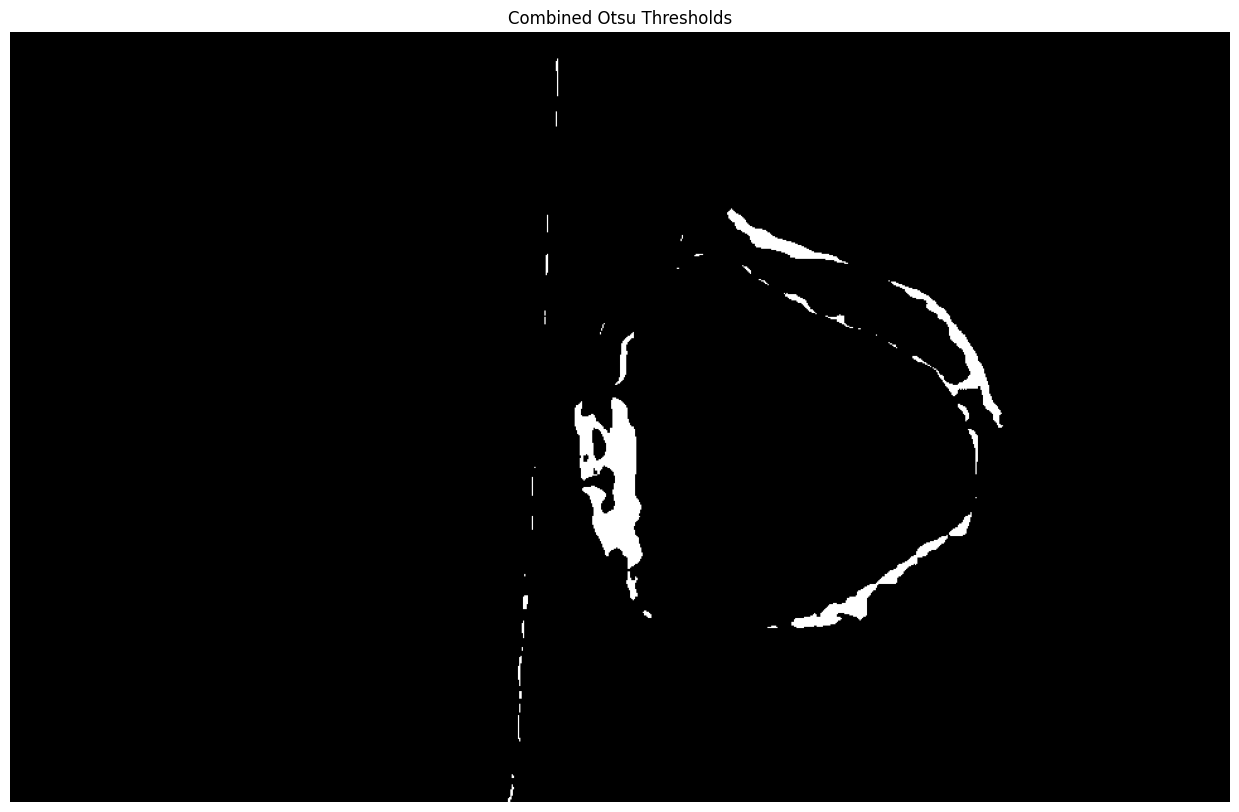

In [4]:
# Combine thresholded channels
otsu_thresh = cv.bitwise_and(thresh_cr, thresh_cb, mask=thresh_cr)

plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Combined Otsu Thresholds')
plt.imshow(otsu_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

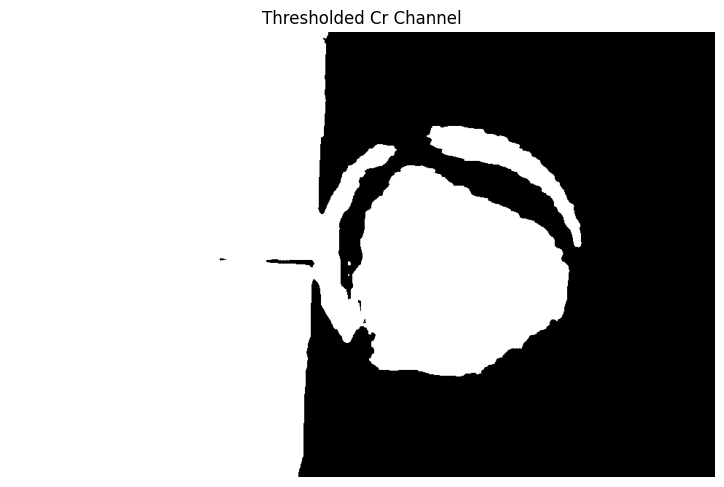

In [5]:
# Threshold on Cr channel
_, thresh_cr = cv.threshold(Cr, thresh=130, maxval=255, type=cv.THRESH_BINARY)

plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.title('Thresholded Cr Channel')
plt.imshow(thresh_cr, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

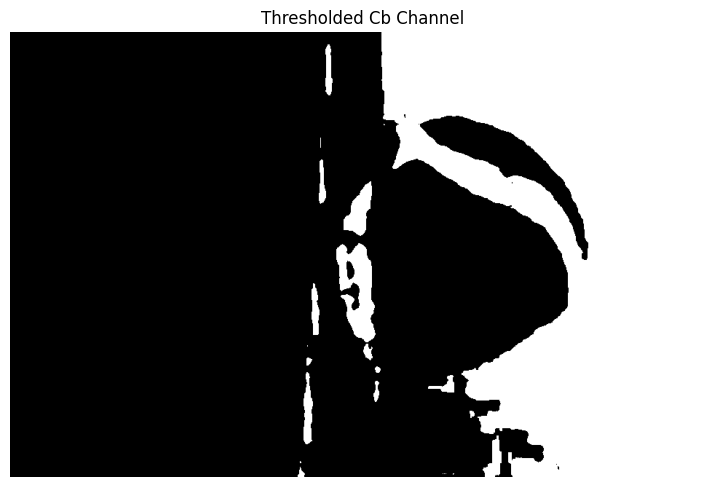

In [6]:
# Threshold on cb channel
_, thresh_cb = cv.threshold(Cb, thresh=120, maxval=255, type=cv.THRESH_BINARY)

plt.figure(figsize=(20,10))
plt.subplot(1,2,2)
plt.title('Thresholded Cb Channel')
plt.imshow(thresh_cb, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

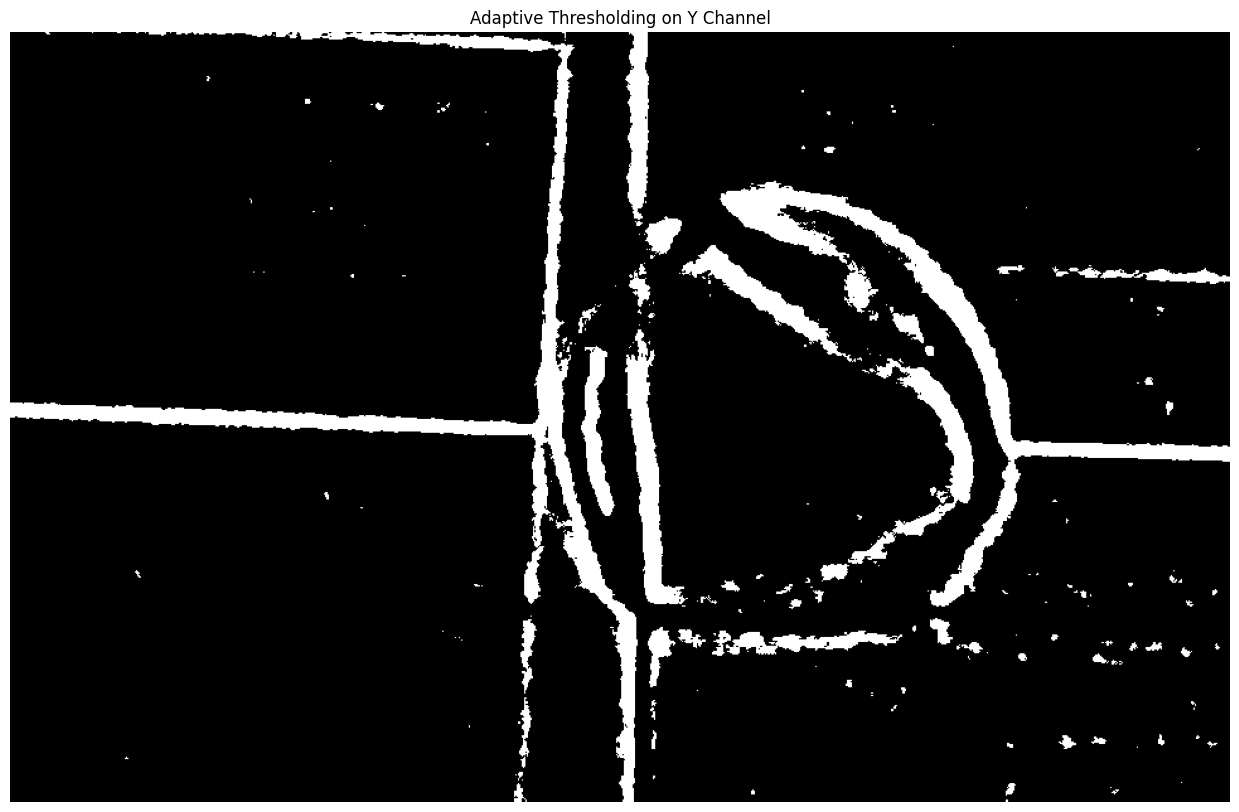

In [7]:
# Apply adaptive thresholding to the Y channel to filter out lines
Y = cv.medianBlur(Y, 3)
adaptive_thresh = cv.adaptiveThreshold(Y, maxValue=255, adaptiveMethod=cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       thresholdType=cv.THRESH_BINARY, blockSize=49, C=-5)


plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Adaptive Thresholding on Y Channel')
plt.imshow(adaptive_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

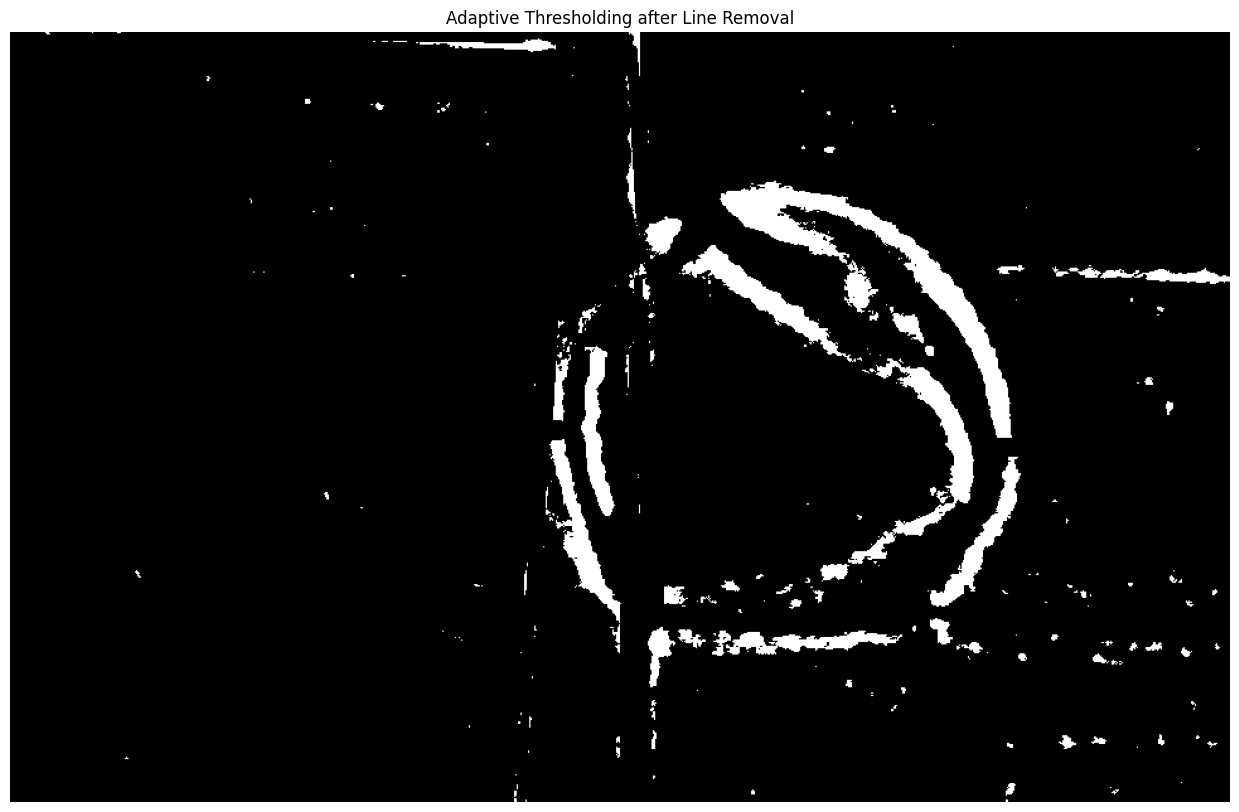

In [8]:
# Detect the inner and outer edge of the court line using hough transform
lines = cv.HoughLinesP(adaptive_thresh, rho=1, theta=np.pi/180, threshold=250,
                        minLineLength=50, maxLineGap=10)

# Remove detected lines from adaptive_thresh
if lines is not None: # Check if any lines were detected
    for line in lines:
        x1, y1, x2, y2 = line[0] # Extract line endpoints
        cv.line(adaptive_thresh, pt1=(x1, y1), pt2=(x2, y2), color=(0), thickness=5)


plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Adaptive Thresholding after Line Removal')
plt.imshow(adaptive_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

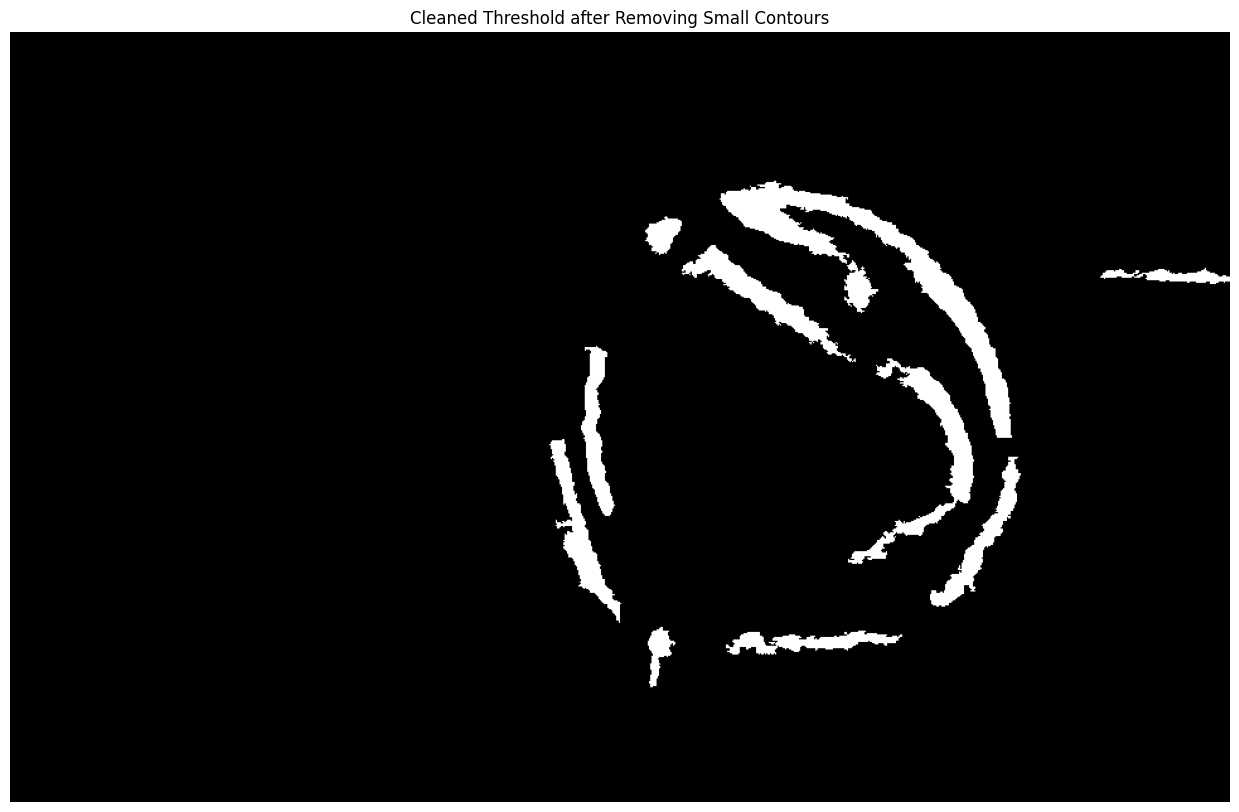

In [9]:
# Clean threshold by removing small contours

contours, _ = cv.findContours(adaptive_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
min_contour_area = 400  # Minimum area threshold
cleaned_thresh = np.zeros_like(adaptive_thresh)
for contour in contours:
    if cv.contourArea(contour) >= min_contour_area:
        cv.drawContours(cleaned_thresh, [contour], -1, color=255, thickness=-1)

plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Cleaned Threshold after Removing Small Contours')
plt.imshow(cleaned_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

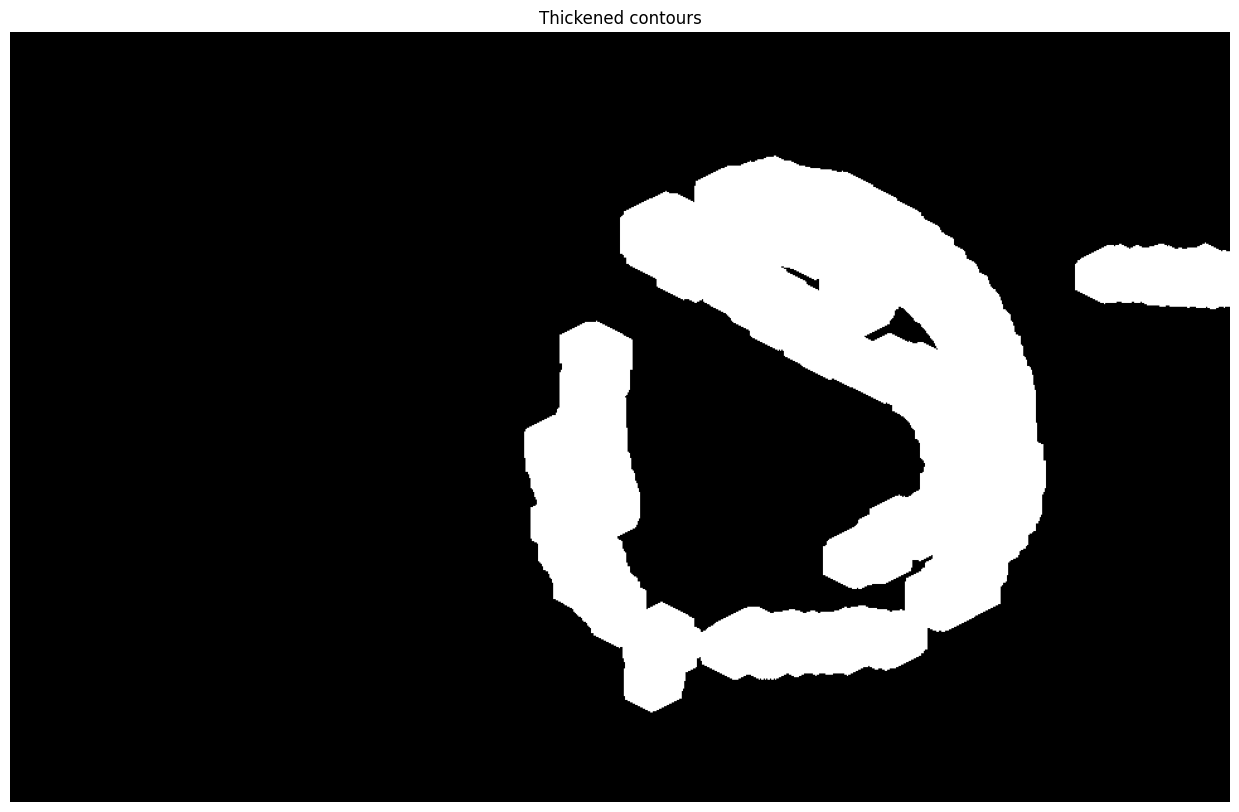

In [10]:
# Close gaps in the detected contours
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
closed_thresh = cv.morphologyEx(cleaned_thresh, cv.MORPH_CLOSE, kernel, iterations=2)

# Dialate to further close gaps
closed_thresh = cv.dilate(closed_thresh, kernel, iterations=10)

# Remove small noise
closed_thresh = cv.morphologyEx(closed_thresh, cv.MORPH_OPEN, kernel, iterations=2)


plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Thickened contours')
plt.imshow(closed_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

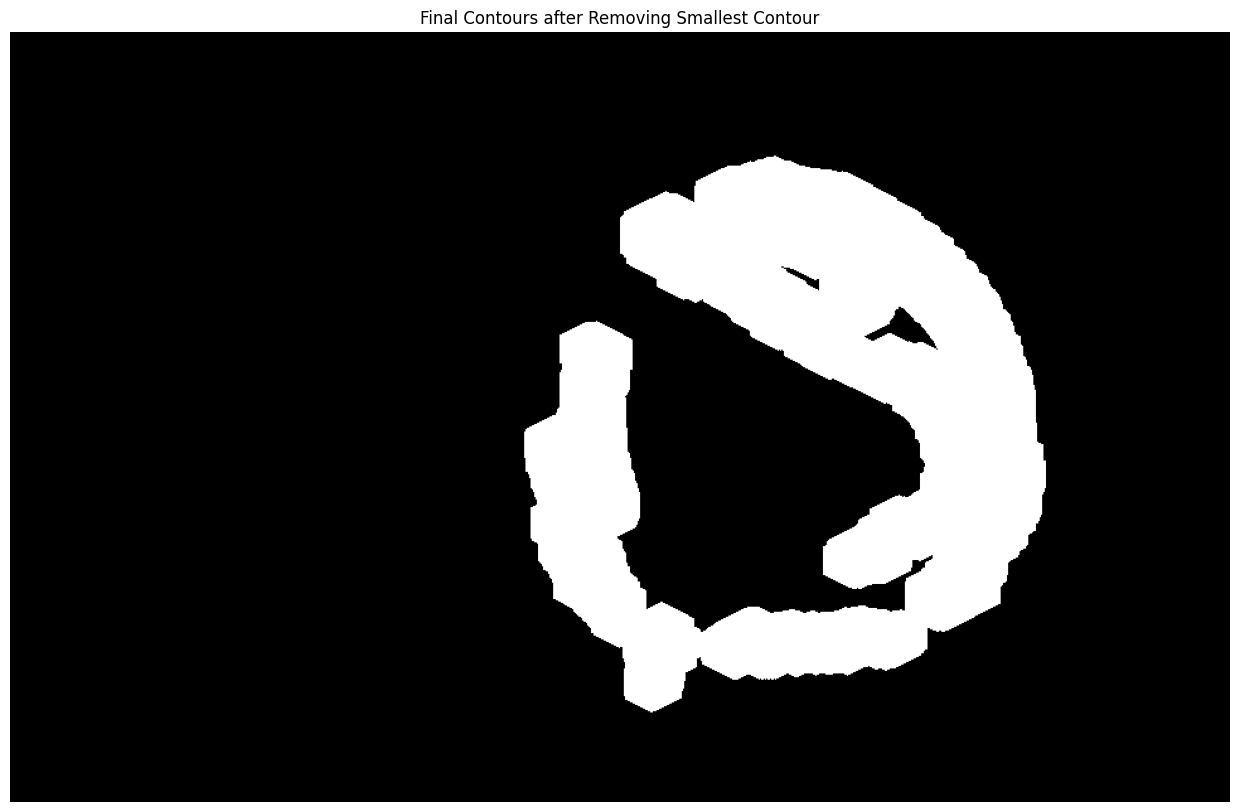

In [11]:
# Find and sort contours by area 
contours, _ = cv.findContours(closed_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
contours = sorted(contours, key=cv.contourArea)

# Remove the smallest contour
contours = contours[0:-1]  # Keep all but the smallest contour
for contour in contours:
    cv.drawContours(closed_thresh, [contour], -1, color=0, thickness=-1)
plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Final Contours after Removing Smallest Contour')
plt.imshow(closed_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

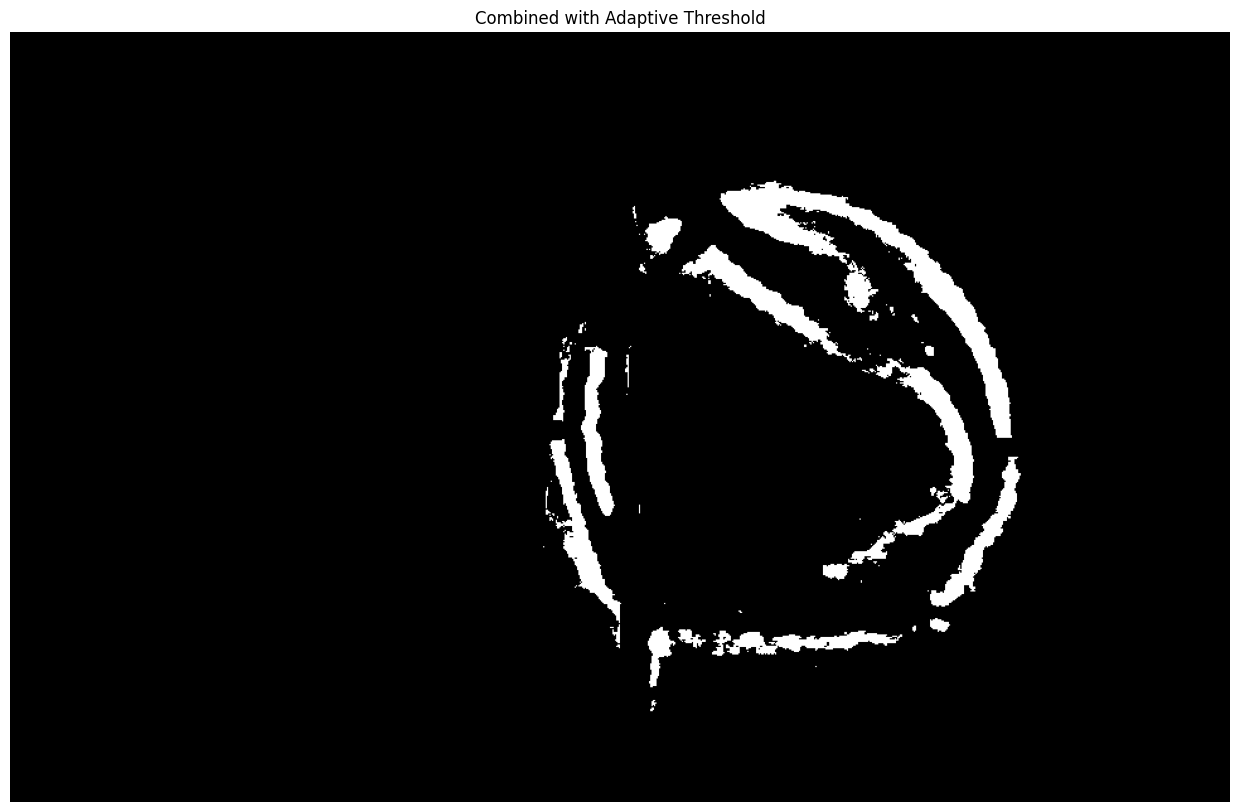

In [12]:
# Combine with adaptive threshold
cleaned_thresh = cv.bitwise_and(closed_thresh, adaptive_thresh, mask=closed_thresh)
plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Combined with Adaptive Threshold')
plt.imshow(cleaned_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

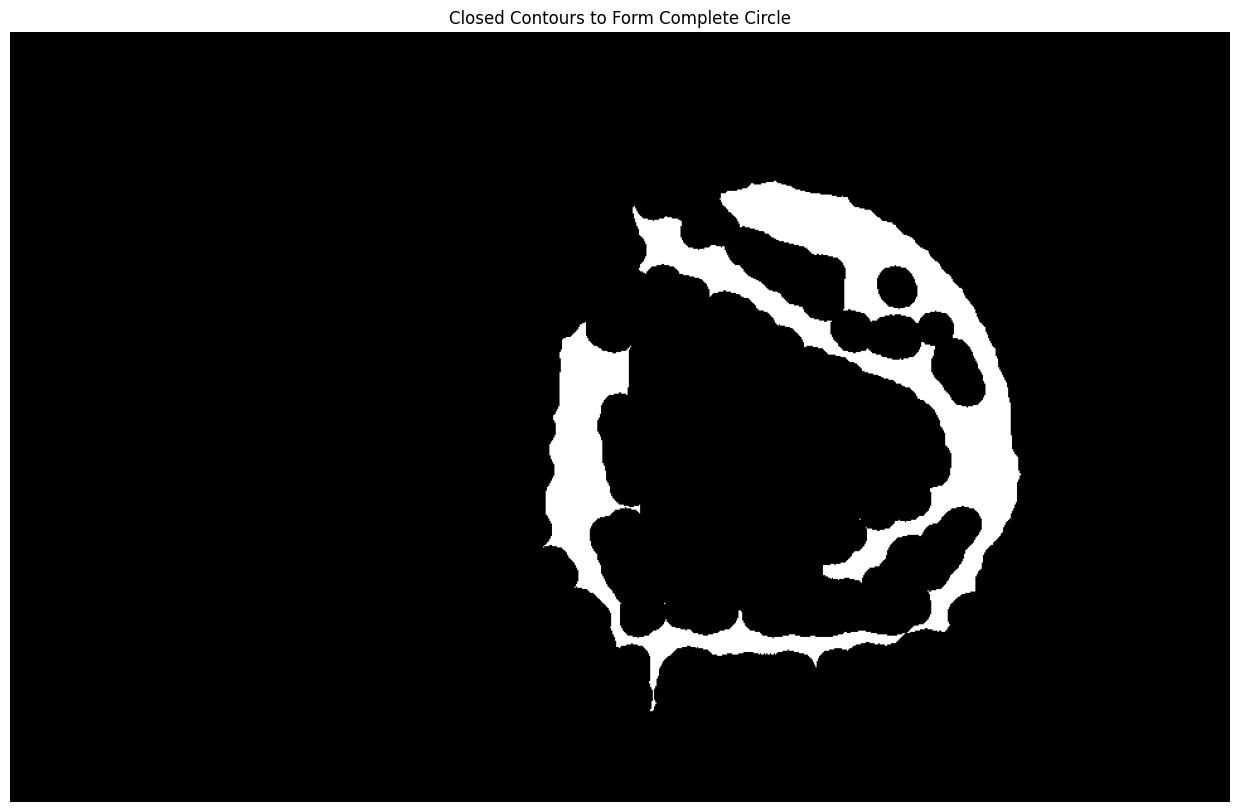

In [13]:
# Close gaps to form a complete circle
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15,15))
closed_thresh = cv.morphologyEx(cleaned_thresh, cv.MORPH_CLOSE, kernel, iterations=2)

plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Closed Contours to Form Complete Circle')
plt.imshow(closed_thresh, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(967.5), np.float64(610.5), np.float64(-0.5))

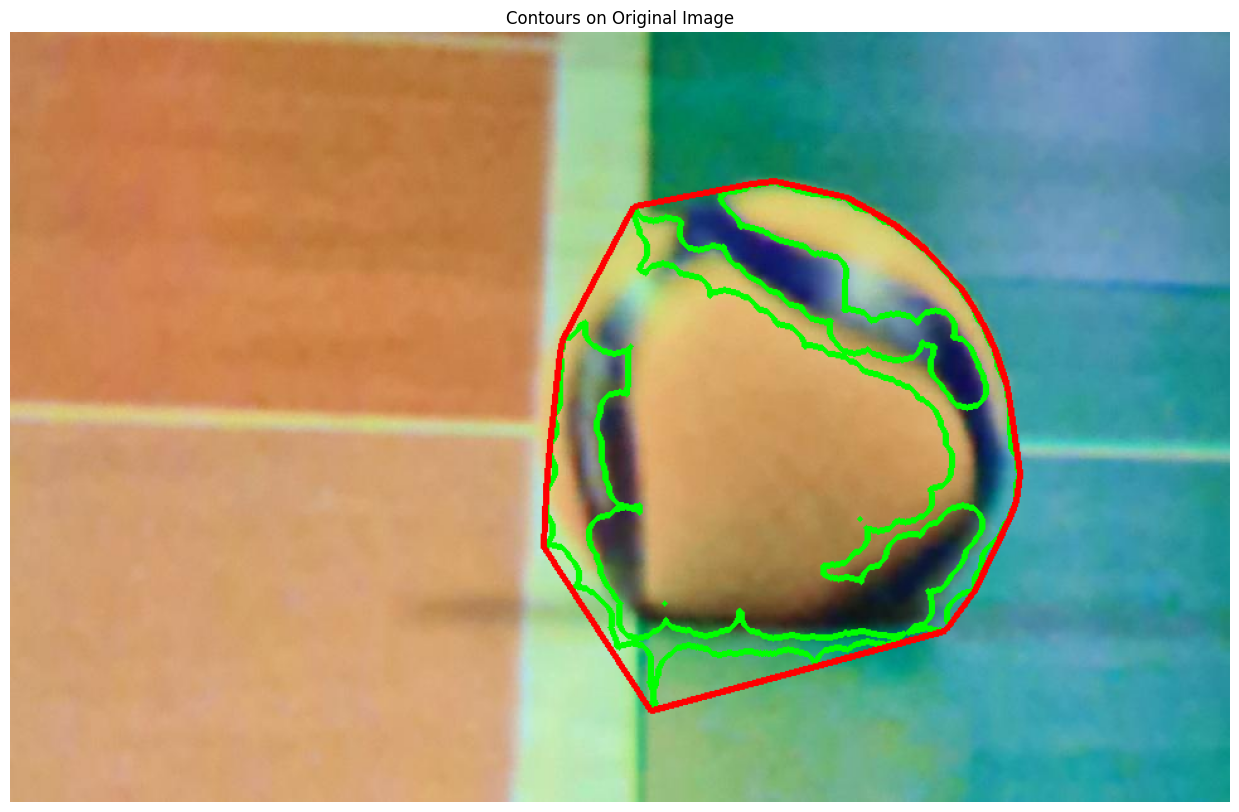

In [14]:
# Find contours that are circular in shape
contours, _ = cv.findContours(closed_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
image = cv.drawContours(image, contours=contours, contourIdx=-1, color=(0,255,0), thickness=3)

# Combine the two largest contours
contours = sorted(contours, key=cv.contourArea)
largest_contour = max(contours, key=cv.contourArea)
second_largest_contour = contours[-2]
combined_contour = np.concatenate((largest_contour, second_largest_contour))


# Clean contour
hull = cv.convexHull(combined_contour)
image = cv.drawContours(image, contours=[hull], contourIdx=-1, color=(0,0,255), thickness=3)

    
plt.figure(figsize=(20,10))
plt.subplot(1,1,1)
plt.title('Contours on Original Image')
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.axis('off')